## Visualising the Cleaned Dataset
The cells below run `load_and_clean()` and visualise the result. They execute only when this notebook is run directly.

In [1]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("vicsuperman/prediction-of-music-genre")

# Run step-by-step to track row count at each stage for the provenance chart
raw = pd.read_csv(os.path.join(path, "music_genre.csv"))
counts = {"Loaded": len(raw)}

bad_values = ["", " ", "?", -1, "-1"]
mask = raw.isna() | raw.isin(bad_values)
df = raw[~mask.any(axis=1)].reset_index(drop=True)
df["tempo"] = pd.to_numeric(df["tempo"], errors="coerce")
df = df.dropna(subset=["tempo"]).reset_index(drop=True)
counts["Bad values\nremoved"] = len(df)

n = len(df)
df = df.drop_duplicates().reset_index(drop=True)
counts["Exact dupes\nremoved"] = len(df)

key_cols = ["artist_name", "track_name"]
non_num = df.select_dtypes(exclude="number").columns.difference(key_cols)
conflict = (
    df.groupby(key_cols)[non_num]
      .transform(lambda c: c.nunique(dropna=False) > 1)
      .any(axis=1)
)
df = df[~conflict].reset_index(drop=True)
counts["Conflicting\ndupes removed"] = len(df)

df = df.drop(columns=["artist_name", "track_name", "instance_id", "obtained_date"])
counts["Final"] = len(df)

print("Cleaning complete:", df.shape)

/Users/scottwu/Documents/Code/AcademicProjects/Intro_to_ML_A02/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cleaning complete: (35480, 14)


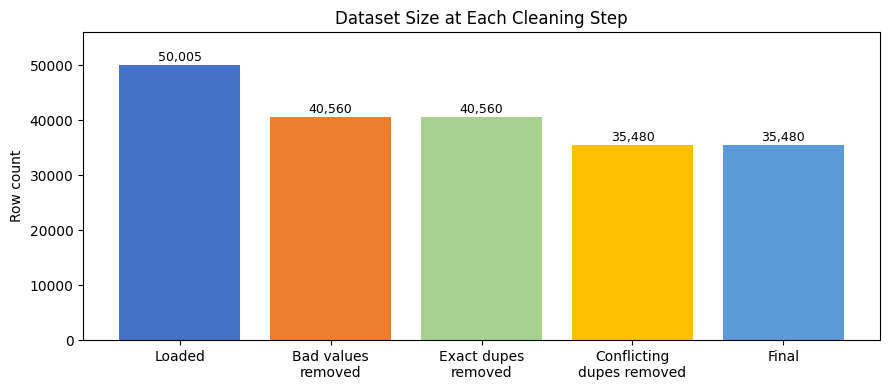

In [2]:
# Cleaning provenance — row count at each step
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#4472C4", "#ED7D31", "#A9D18E", "#FFC000", "#5B9BD5"]
bars = ax.bar(list(counts.keys()), list(counts.values()), color=colors)
ax.set_ylabel("Row count")
ax.set_title("Dataset Size at Each Cleaning Step")
ax.set_ylim(0, max(counts.values()) * 1.12)
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

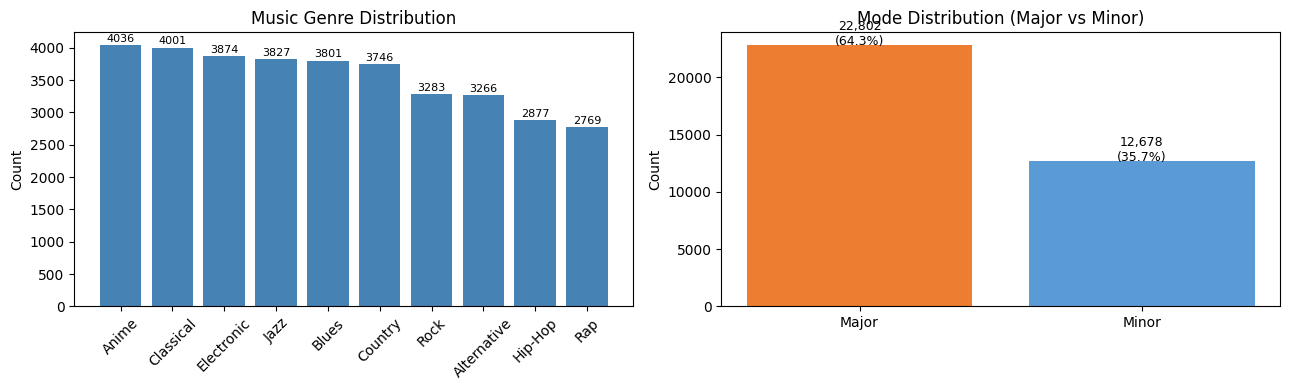

In [3]:
# Class distributions: genre and mode
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

genre_counts = df["music_genre"].value_counts()
axes[0].bar(genre_counts.index, genre_counts.values, color="steelblue")
axes[0].set_title("Music Genre Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
for i, v in enumerate(genre_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=8)

mode_counts = df["mode"].value_counts()
bar_colors = ["#ED7D31" if m == "Major" else "#5B9BD5" for m in mode_counts.index]
axes[1].bar(mode_counts.index, mode_counts.values, color=bar_colors)
axes[1].set_title("Mode Distribution (Major vs Minor)")
axes[1].set_ylabel("Count")
for i, v in enumerate(mode_counts.values):
    axes[1].text(i, v + 50, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

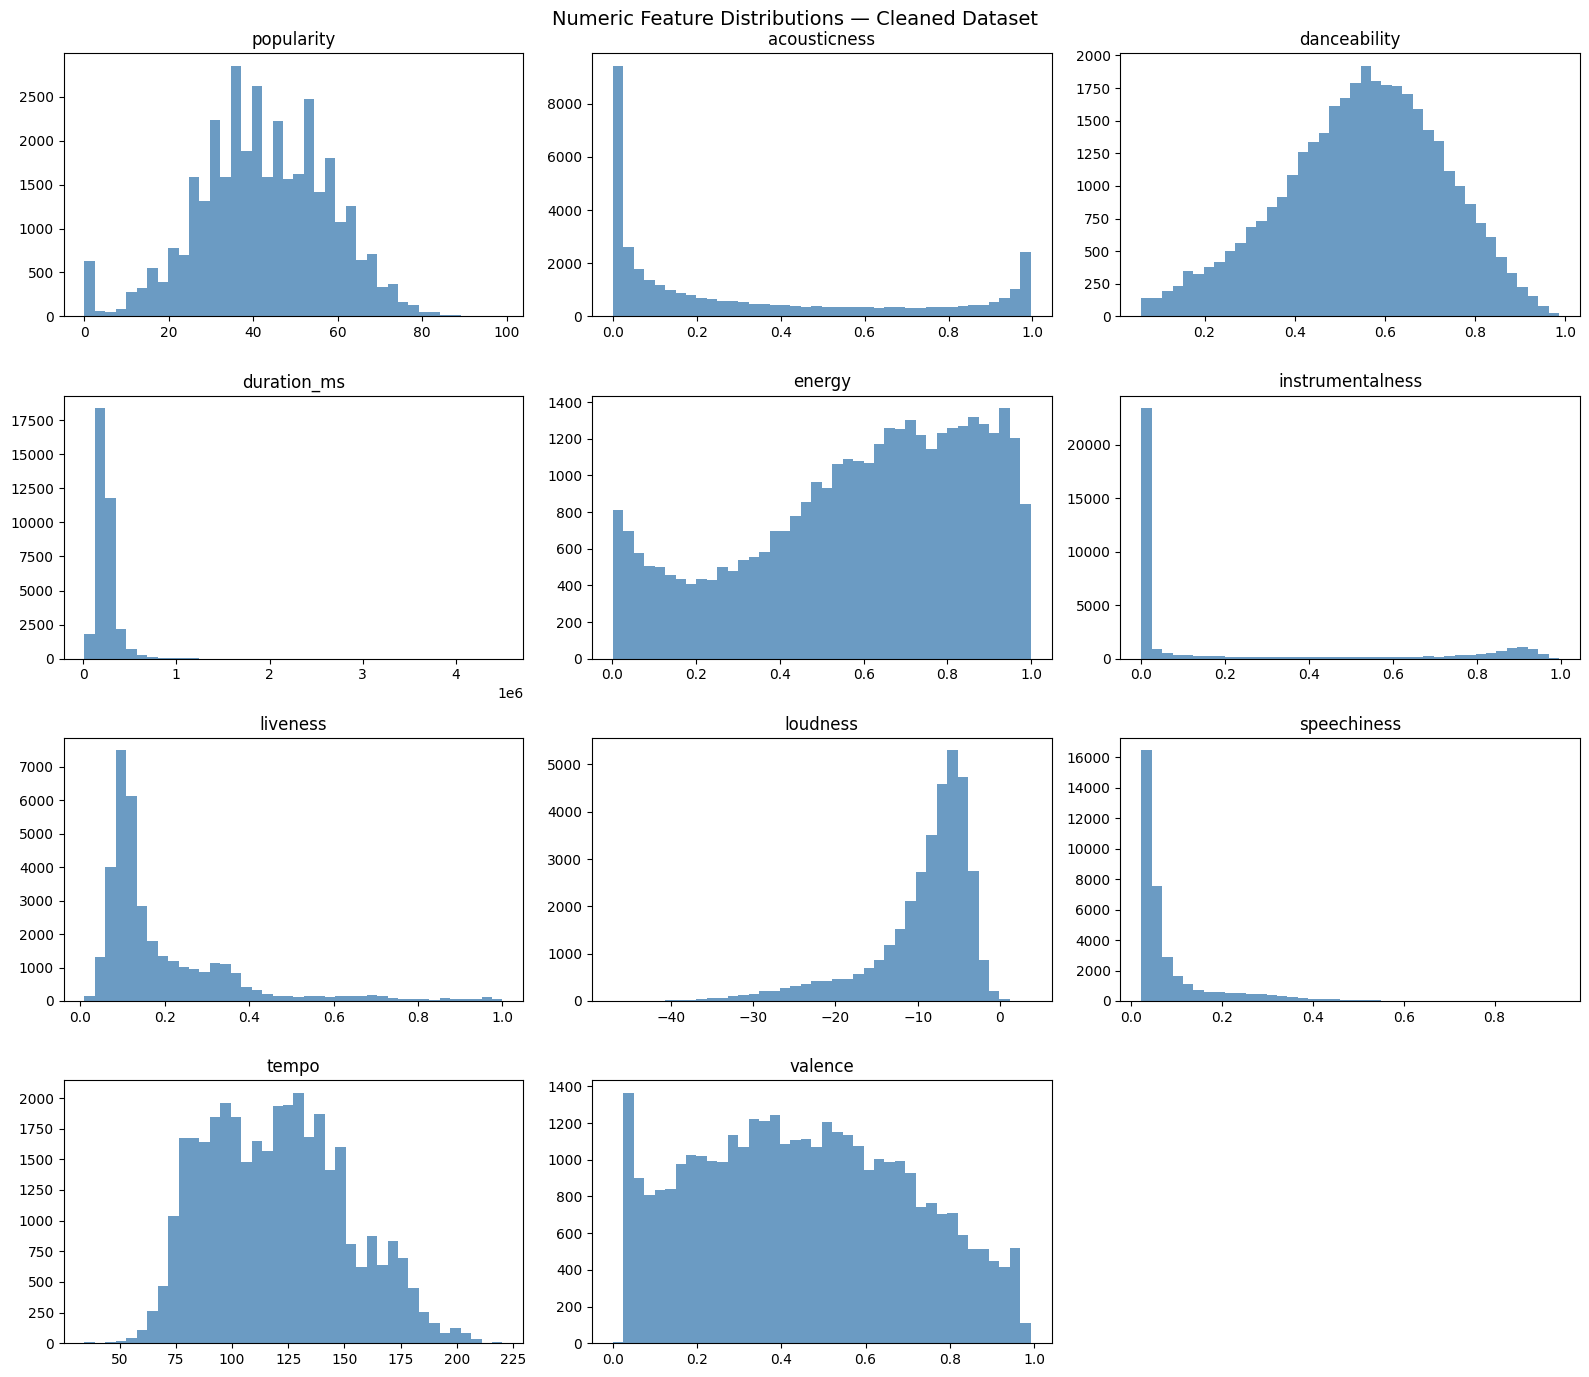

In [4]:
# Numeric feature distributions
numeric_features = [
    "popularity", "acousticness", "danceability", "duration_ms",
    "energy", "instrumentalness", "liveness", "loudness",
    "speechiness", "tempo", "valence"
]
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, feat in enumerate(numeric_features):
    axes[i].hist(df[feat], bins=40, color="steelblue", edgecolor="none", alpha=0.8)
    axes[i].set_title(feat)
fig.delaxes(axes[11])
plt.suptitle("Numeric Feature Distributions — Cleaned Dataset", fontsize=14)
plt.tight_layout()
plt.show()

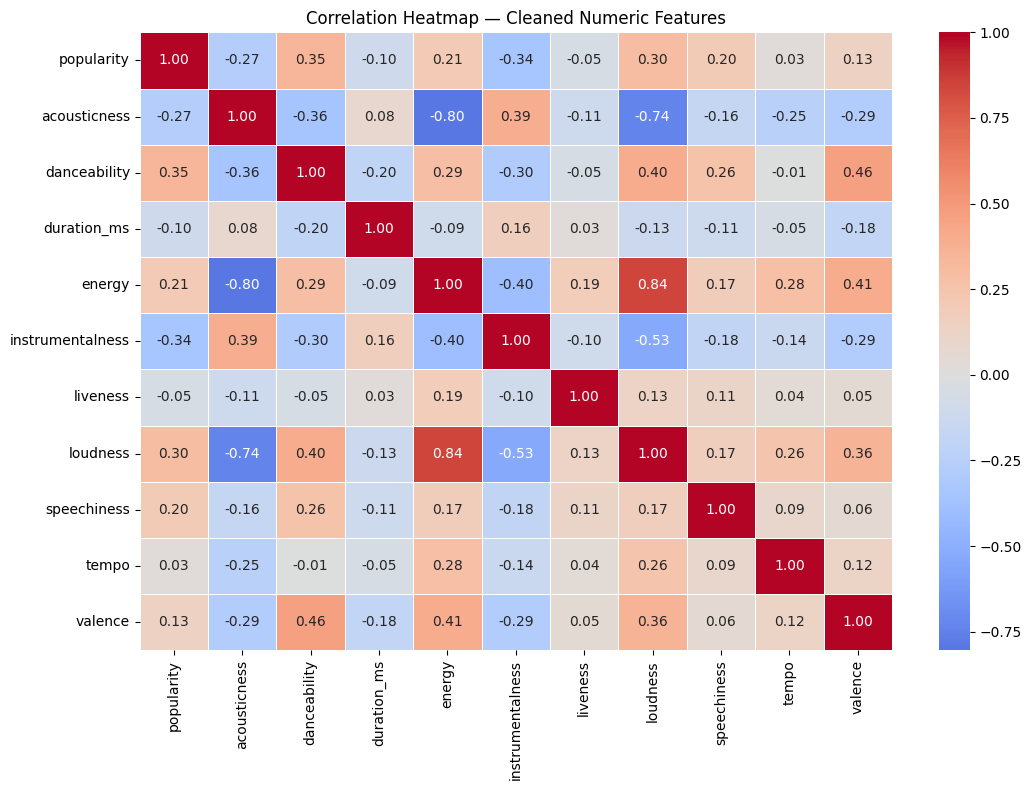

In [5]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(
    df[numeric_features].corr(),
    annot=True, cmap="coolwarm", fmt=".2f", center=0, linewidths=0.4
)
plt.title("Correlation Heatmap — Cleaned Numeric Features")
plt.tight_layout()
plt.show()